# Deep Learning Individual Project — Label Smoothing Experiment

**Student ID:** s3343711

---

## Experiment Overview

This notebook explores **Label Smoothing** as a regularization technique to potentially improve model generalization.

### Dataset Observations
Each class has distinct visual patterns:
- **Class 0**: Dash-like shape
- **Class 1**: 3 lines shape
- **Class 2**: 2 lines shape
- **Class 3**: Sphere shape

### What is Label Smoothing?
Instead of using hard labels like `[0, 0, 1, 0]`, label smoothing uses soft labels like `[0.025, 0.025, 0.925, 0.025]`.

**Formula:**
$$y_{smooth} = (1 - \alpha) \cdot y_{hard} + \frac{\alpha}{K}$$

Where:
- $\alpha$ = smoothing factor (e.g., 0.1)
- $K$ = number of classes
- $y_{hard}$ = original one-hot label

**Benefits:**
1. Prevents overconfident predictions
2. Better calibrated probability outputs
3. Can improve generalization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from typing import Any

# Global constants
RANDOM_SEED = 42
SAMPLES_PER_CLASS_VISUALIZATION = 6

# Color palette for visualization
COLOR_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# Set random seeds
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {RANDOM_SEED}")


c:\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.

TensorFlow version: 2.20.0
Random seed: 42


---

## Visualization Helper Functions


In [2]:
def plot_training_history(history, title_prefix="", figsize=(14, 5)):
    """Plot training and validation accuracy/loss curves."""
    figure, axes = plt.subplots(1, 2, figsize=figsize)
    prefix = f"{title_prefix} " if title_prefix else ""

    # Accuracy plot
    axes[0].plot(history.history["accuracy"], label="Training", linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2)
    axes[0].set_title(f"{prefix}Model Accuracy", fontsize=14)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history.history["loss"], label="Training", linewidth=2)
    axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2)
    axes[1].set_title(f"{prefix}Model Loss", fontsize=14)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "epochs": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "best_val_accuracy": max(history.history["val_accuracy"]),
    }


def plot_confusion_matrices(y_true, y_pred, class_names, figsize=(14, 5)):
    """Plot confusion matrices (counts and percentages) side by side."""
    num_classes = len(class_names)
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = (
        conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    )

    figure, axes = plt.subplots(1, 2, figsize=figsize)

    def plot_single_matrix(axis, matrix, title, fmt_func, threshold_func):
        im = axis.imshow(matrix, cmap="Blues")
        axis.set_title(title, fontsize=14)
        axis.set_xlabel("Predicted Label")
        axis.set_ylabel("True Label")
        axis.set_xticks(range(num_classes))
        axis.set_yticks(range(num_classes))
        axis.set_xticklabels(class_names)
        axis.set_yticklabels(class_names)

        for row in range(num_classes):
            for col in range(num_classes):
                text_color = "white" if threshold_func(matrix[row, col]) else "black"
                axis.text(
                    col, row, fmt_func(matrix[row, col]),
                    ha="center", va="center", color=text_color,
                    fontsize=12, fontweight="bold"
                )
        return im

    # Raw counts
    im1 = plot_single_matrix(
        axes[0], conf_matrix, "Confusion Matrix (Counts)",
        lambda x: f"{x}", lambda x: x > conf_matrix.max() / 2
    )
    plt.colorbar(im1, ax=axes[0])

    # Percentages
    im2 = plot_single_matrix(
        axes[1], conf_matrix_normalized, "Confusion Matrix (Percentages)",
        lambda x: f"{x:.1f}%", lambda x: x > 50
    )
    plt.colorbar(im2, ax=axes[1], format="%.0f%%")

    plt.tight_layout()
    plt.show()

    # Print per-class accuracy
    print("\nPer-Class Accuracy:")
    print("-" * 40)
    for i in range(num_classes):
        accuracy = conf_matrix[i, i] / conf_matrix[i, :].sum() * 100
        print(f"{class_names[i]}: {accuracy:.2f}%")


def plot_sample_predictions(images, true_labels, pred_labels, class_names, 
                            num_classes, samples_per_class, figsize=(14, 10), seed=42):
    """Plot sample predictions with correct/incorrect color coding."""
    np.random.seed(seed)
    figure, axes = plt.subplots(num_classes, samples_per_class, figsize=figsize)
    figure.suptitle("Sample Predictions (Green=Correct, Red=Incorrect)", fontsize=14)

    sample_indices = []
    for class_idx in range(num_classes):
        class_indices = np.where(true_labels == class_idx)[0]
        selected = np.random.choice(class_indices, size=samples_per_class, replace=False)
        sample_indices.extend(selected)

    for idx, sample_idx in enumerate(sample_indices):
        row = idx // samples_per_class
        col = idx % samples_per_class

        image = images[sample_idx]
        if image.ndim == 3:
            image = image[:, :, 0]

        true_label = true_labels[sample_idx]
        pred_label = pred_labels[sample_idx]

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        is_correct = true_label == pred_label
        title_color = "green" if is_correct else "red"
        axes[row, col].set_title(f"T:{true_label} P:{pred_label}", color=title_color, fontsize=12)

    plt.tight_layout()
    plt.show()

    correct = np.sum(pred_labels == true_labels)
    total = len(true_labels)
    print(f"\nPrediction Summary:")
    print(f"  Correct: {correct:,} ({correct/total*100:.2f}%)")
    print(f"  Incorrect: {total-correct:,} ({(total-correct)/total*100:.2f}%)")


def plot_training_comparison(history1, history2, label1="Baseline", label2="Label Smoothing", figsize=(14, 10)):
    """Plot side-by-side comparison of two training histories."""
    figure, axes = plt.subplots(2, 2, figsize=figsize)
    figure.suptitle(f"Training Comparison: {label1} vs {label2}", fontsize=14)

    plot_configs = [
        (0, 0, history1, "accuracy", f"{label1} Accuracy", "tab:blue"),
        (0, 1, history2, "accuracy", f"{label2} Accuracy", "tab:green"),
        (1, 0, history1, "loss", f"{label1} Loss", "tab:blue"),
        (1, 1, history2, "loss", f"{label2} Loss", "tab:green"),
    ]

    for row, col, hist, metric, title, color in plot_configs:
        ax = axes[row, col]
        ax.plot(hist.history[metric], label="Training", linestyle="-", linewidth=2, color=color)
        ax.plot(hist.history[f"val_{metric}"], label="Validation", linestyle="--", linewidth=2, color=color, alpha=0.7)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


---

## Load and Explore Dataset


In [3]:
# Load Dataset
dataset = np.load("4class_32x32.npz")
X = dataset["X"]
y = dataset["y"]

# Discover dataset properties
UNIQUE_CLASSES = np.unique(y)
NUM_CLASSES = len(UNIQUE_CLASSES)
TOTAL_SAMPLES = len(y)

# Generate class names with visual patterns
CLASS_NAMES = ["Class 0 (Dash)", "Class 1 (3-Lines)", "Class 2 (2-Lines)", "Class 3 (Sphere)"]
CLASS_COLORS = COLOR_PALETTE[:NUM_CLASSES]

# Display dataset structure
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Images array (X): {X.shape}, dtype: {X.dtype}")
print(f"Labels array (y): {y.shape}, dtype: {y.dtype}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Total samples: {TOTAL_SAMPLES:,}")
print(f"\nClass Visual Patterns:")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y == i)
    print(f"  {name}: {count:,} samples")


DATASET OVERVIEW
Images array (X): (16000, 32, 32), dtype: float32
Labels array (y): (16000,), dtype: int64
Number of classes: 4
Total samples: 16,000

Class Visual Patterns:
  Class 0 (Dash): 4,000 samples
  Class 1 (3-Lines): 4,000 samples
  Class 2 (2-Lines): 4,000 samples
  Class 3 (Sphere): 4,000 samples


---

## Data Splitting and Preprocessing

**Important:** Data is split BEFORE preprocessing to prevent data leakage.


In [4]:
# STEP 1: Split data BEFORE preprocessing (70% train, 15% val, 15% test)

# First split: separate test set (15% of total data)
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)

# Second split: separate train and validation from remaining data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp
)

print("Data Split Summary:")
print("=" * 50)
print(f"Training set:   {X_train_raw.shape[0]:,} samples ({X_train_raw.shape[0]/len(y)*100:.1f}%)")
print(f"Validation set: {X_val_raw.shape[0]:,} samples ({X_val_raw.shape[0]/len(y)*100:.1f}%)")
print(f"Test set:       {X_test_raw.shape[0]:,} samples ({X_test_raw.shape[0]/len(y)*100:.1f}%)")

# Verify stratification
print("\nClass Distribution in Splits:")
print(f"{'Class':<20} {'Train':<12} {'Validation':<12} {'Test':<12}")
print("-" * 55)
for class_index in range(NUM_CLASSES):
    train_count = np.sum(y_train == class_index)
    val_count = np.sum(y_val == class_index)
    test_count = np.sum(y_test == class_index)
    print(f"{CLASS_NAMES[class_index]:<20} {train_count:<12} {val_count:<12} {test_count:<12}")


Data Split Summary:
Training set:   11,206 samples (70.0%)
Validation set: 2,394 samples (15.0%)
Test set:       2,400 samples (15.0%)

Class Distribution in Splits:
Class                Train        Validation   Test        
-------------------------------------------------------
Class 0 (Dash)       2801         599          600         
Class 1 (3-Lines)    2802         598          600         
Class 2 (2-Lines)    2801         599          600         
Class 3 (Sphere)     2802         598          600         


In [5]:
# STEP 2: Compute normalization statistics from TRAINING DATA ONLY
PIXEL_MIN = X_train_raw.min()
PIXEL_MAX = X_train_raw.max()

print(f"Normalization Statistics (from training data only):")
print(f"  PIXEL_MIN: {PIXEL_MIN:.4f}")
print(f"  PIXEL_MAX: {PIXEL_MAX:.4f}")


# STEP 3: Define preprocessing function
def preprocess_data(X_raw, pixel_min=PIXEL_MIN, pixel_max=PIXEL_MAX):
    """Normalize and add channel dimension."""
    X_normalized = (X_raw - pixel_min) / (pixel_max - pixel_min)
    X_normalized = np.clip(X_normalized, 0, 1)
    X_processed = X_normalized[..., np.newaxis]
    return X_processed.astype(np.float32)


# STEP 4: Apply preprocessing to all splits
X_train = preprocess_data(X_train_raw)
X_val = preprocess_data(X_val_raw)
X_test = preprocess_data(X_test_raw)

print("\nPreprocessing Applied:")
print(f"  X_train: {X_train.shape}, range [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  X_val:   {X_val.shape}, range [{X_val.min():.4f}, {X_val.max():.4f}]")
print(f"  X_test:  {X_test.shape}, range [{X_test.min():.4f}, {X_test.max():.4f}]")


Normalization Statistics (from training data only):
  PIXEL_MIN: 0.0000
  PIXEL_MAX: 5.0696



Preprocessing Applied:
  X_train: (11206, 32, 32, 1), range [0.0000, 1.0000]
  X_val:   (2394, 32, 32, 1), range [0.0000, 0.9922]
  X_test:  (2400, 32, 32, 1), range [0.0000, 0.9910]


---

## Model Architecture

We use the same CNN architecture as the baseline, but with **Label Smoothing** in the loss function.


In [6]:
def build_cnn_model(input_shape, num_classes, label_smoothing=0.0, learning_rate=0.001):
    """
    Build a CNN model for image classification.
    
    Parameters:
        input_shape: tuple, shape of input images (height, width, channels)
        num_classes: int, number of output classes
        label_smoothing: float, label smoothing factor (0.0 = no smoothing)
        learning_rate: float, learning rate for Adam optimizer
        
    Returns:
        model: compiled Keras model
    """
    inputs = layers.Input(shape=input_shape)
    
    # First Convolutional Block
    x = layers.Conv2D(32, (3, 3), padding='valid')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Second Convolutional Block
    x = layers.Conv2D(64, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Third Convolutional Block
    x = layers.Conv2D(128, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Fully Connected Layers
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile with label smoothing in the loss function
    # Note: CategoricalCrossentropy requires one-hot encoded labels
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy']
    )
    
    return model


# Define input shape
INPUT_SHAPE = X_train.shape[1:]  # (32, 32, 1)
print(f"Input shape: {INPUT_SHAPE}")
print(f"Number of classes: {NUM_CLASSES}")

# Convert labels to one-hot encoding for CategoricalCrossentropy
y_train_onehot = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_onehot = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_onehot = keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"\nOne-hot encoded labels:")
print(f"  y_train_onehot shape: {y_train_onehot.shape}")
print(f"  y_val_onehot shape: {y_val_onehot.shape}")
print(f"  y_test_onehot shape: {y_test_onehot.shape}")
print(f"  Example: label {y_train[0]} -> {y_train_onehot[0]}")


Input shape: (32, 32, 1)
Number of classes: 4

One-hot encoded labels:
  y_train_onehot shape: (11206, 4)
  y_val_onehot shape: (2394, 4)
  y_test_onehot shape: (2400, 4)
  Example: label 1 -> [0. 1. 0. 0.]


---

## Train Baseline Model (No Label Smoothing)


In [7]:
# Training configuration
EPOCHS = 50
BATCH_SIZE = 32

# Build baseline model (no label smoothing)
print("Building BASELINE model (no label smoothing)...")
model_baseline = build_cnn_model(
    input_shape=INPUT_SHAPE, 
    num_classes=NUM_CLASSES, 
    label_smoothing=0.0  # No smoothing
)

model_baseline.summary()


Building BASELINE model (no label smoothing)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,084 (398.77 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Reset random seeds
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Define callbacks
baseline_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

print("Training BASELINE model...")
print("=" * 50)

# Use one-hot encoded labels for CategoricalCrossentropy
history_baseline = model_baseline.fit(
    X_train, y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=baseline_callbacks,
    verbose=1
)

print("\n" + "=" * 50)
print("Baseline Training completed!")
print(f"Best validation accuracy: {max(history_baseline.history['val_accuracy']):.4f}")


Training BASELINE model...
Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.8869 - loss: 0.3207 - val_accuracy: 0.2506 - val_loss: 2.7266 - learning_rate: 0.0010
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9448 - loss: 0.1669 - val_accuracy: 0.7210 - val_loss: 1.0300 - learning_rate: 0.0010
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9567 - loss: 0.1331 - val_accuracy: 0.7318 - val_loss: 1.5146 - learning_rate: 0.0010
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9648 - loss: 0.1080 - val_accuracy: 0.7544 - val_loss: 1.0453 - learning_rate: 0.0010
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9711 - loss: 0.0884 - val_accuracy: 0.6759 - val_loss: 3.6484 - learning_rate: 0.0010
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9745 - loss: 0.0762 - val_accuracy: 0.7903 - val_loss: 0.7771 - learning_rate: 0.0010
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/

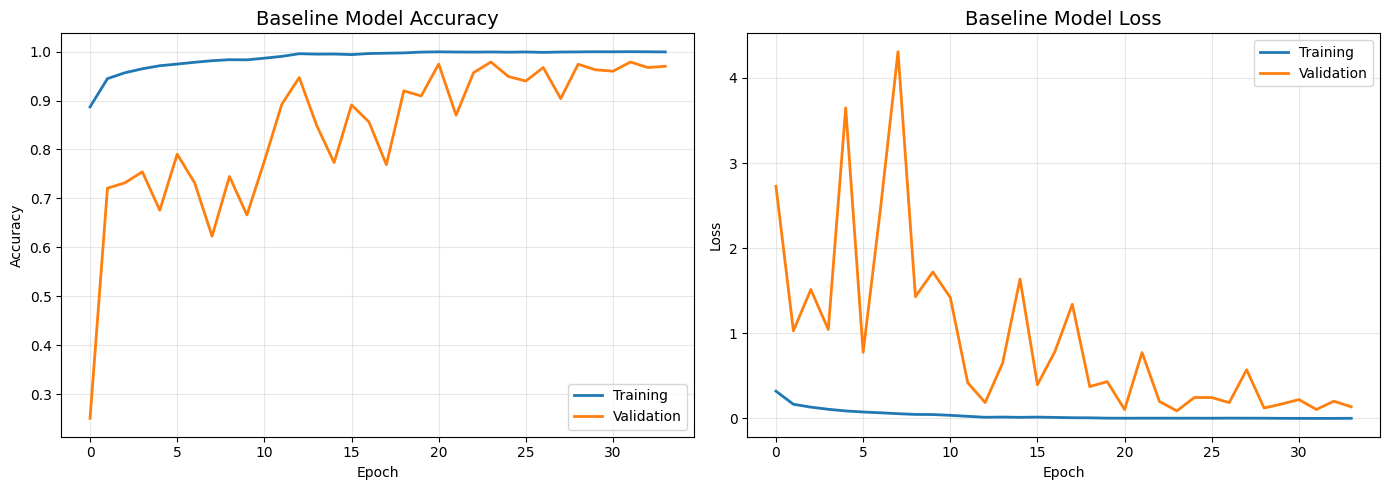


Baseline Training Summary:
  Epochs trained: 34
  Best val accuracy: 0.9787
  Best val loss: 0.0894


In [9]:
# Plot baseline training history
baseline_stats = plot_training_history(history_baseline, title_prefix="Baseline")
print(f"\nBaseline Training Summary:")
print(f"  Epochs trained: {baseline_stats['epochs']}")
print(f"  Best val accuracy: {baseline_stats['best_val_accuracy']:.4f}")
print(f"  Best val loss: {baseline_stats['best_val_loss']:.4f}")


---

## Train Model with Label Smoothing


In [10]:
# Label smoothing factor
LABEL_SMOOTHING = 0.1  # 10% smoothing

print(f"Building model with LABEL SMOOTHING = {LABEL_SMOOTHING}...")
print(f"\nLabel Smoothing Effect:")
print(f"  Hard label [0, 0, 1, 0] becomes:")
smooth_label = np.array([LABEL_SMOOTHING/NUM_CLASSES, LABEL_SMOOTHING/NUM_CLASSES, 
                         1 - LABEL_SMOOTHING + LABEL_SMOOTHING/NUM_CLASSES, 
                         LABEL_SMOOTHING/NUM_CLASSES])
print(f"  Soft label {smooth_label}")

# Build model with label smoothing
model_smoothing = build_cnn_model(
    input_shape=INPUT_SHAPE, 
    num_classes=NUM_CLASSES, 
    label_smoothing=LABEL_SMOOTHING
)

model_smoothing.summary()


Building model with LABEL SMOOTHING = 0.1...

Label Smoothing Effect:
  Hard label [0, 0, 1, 0] becomes:
  Soft label [0.025 0.025 0.925 0.025]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,084 (398.77 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# Reset random seeds for fair comparison
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Define callbacks
smoothing_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

print(f"Training model with LABEL SMOOTHING = {LABEL_SMOOTHING}...")
print("=" * 50)

# Use one-hot encoded labels for CategoricalCrossentropy
history_smoothing = model_smoothing.fit(
    X_train, y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=smoothing_callbacks,
    verbose=1
)

print("\n" + "=" * 50)
print("Label Smoothing Training completed!")
print(f"Best validation accuracy: {max(history_smoothing.history['val_accuracy']):.4f}")


Training model with LABEL SMOOTHING = 0.1...
Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8842 - loss: 0.6114 - val_accuracy: 0.4069 - val_loss: 2.1458 - learning_rate: 0.0010
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.9496 - loss: 0.4873 - val_accuracy: 0.7331 - val_loss: 1.1198 - learning_rate: 0.0010
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9632 - loss: 0.4587 - val_accuracy: 0.8053 - val_loss: 0.7323 - learning_rate: 0.0010
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9693 - loss: 0.4417 - val_accuracy: 0.9632 - val_loss: 0.4420 - learning_rate: 0.0010
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.9743 - loss: 0.4286 - val_accuracy: 0.8534 - val_loss: 0.6235 - learning_rate: 0.0010
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.9797 - loss: 0.4174 - val_accuracy: 0.5434 - val_loss: 1.6377 - learning_rate: 0.0010
Epoch 7/50
351/351 ━━━━━━━━━━━━

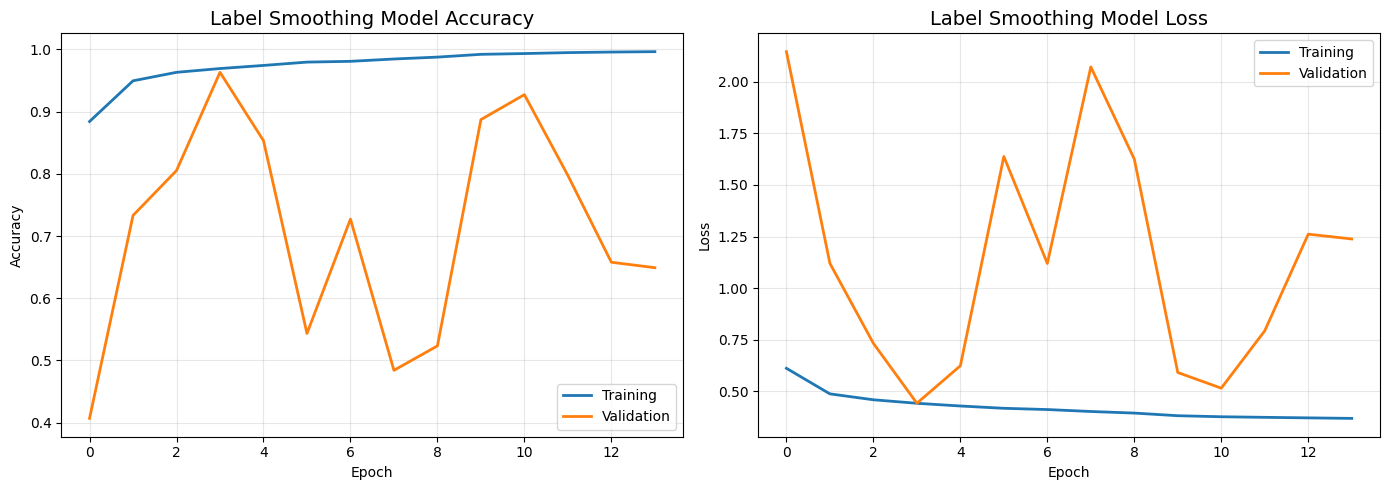


Label Smoothing Training Summary:
  Epochs trained: 14
  Best val accuracy: 0.9632
  Best val loss: 0.4420


In [12]:
# Plot label smoothing training history
smoothing_stats = plot_training_history(history_smoothing, title_prefix="Label Smoothing")
print(f"\nLabel Smoothing Training Summary:")
print(f"  Epochs trained: {smoothing_stats['epochs']}")
print(f"  Best val accuracy: {smoothing_stats['best_val_accuracy']:.4f}")
print(f"  Best val loss: {smoothing_stats['best_val_loss']:.4f}")


---

## Compare Training Curves


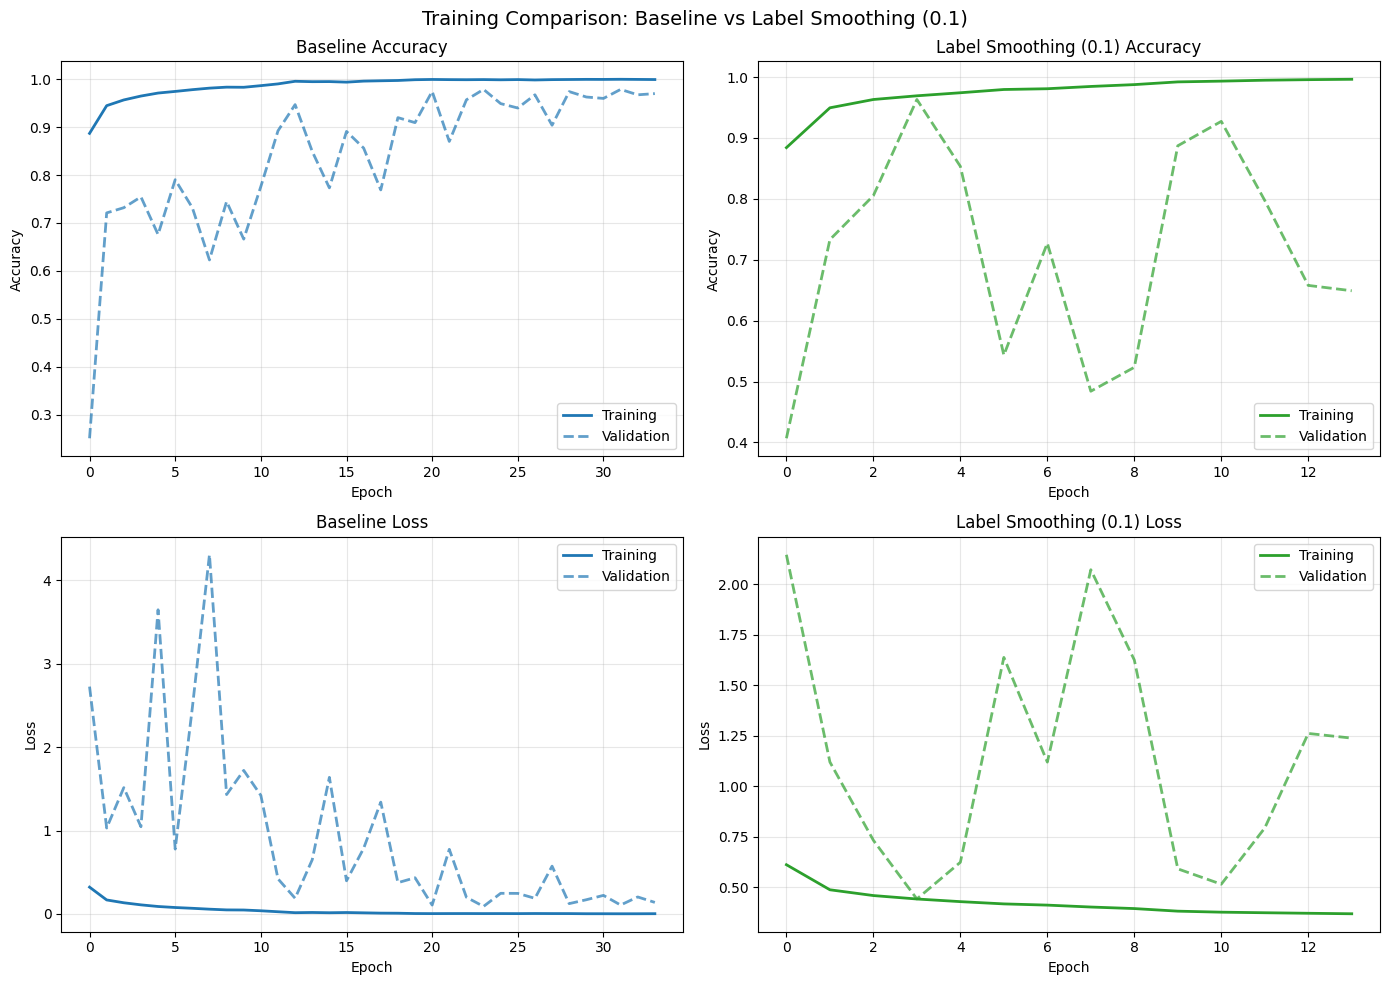

In [13]:
# Compare training curves
plot_training_comparison(history_baseline, history_smoothing, 
                         label1="Baseline", label2=f"Label Smoothing ({LABEL_SMOOTHING})")


---

## Validation Set Evaluation


In [14]:
# Evaluate both models on validation set
print("VALIDATION SET EVALUATION")
print("=" * 70)

# Baseline model (use one-hot labels for evaluation)
baseline_val_loss, baseline_val_accuracy = model_baseline.evaluate(X_val, y_val_onehot, verbose=0)
y_val_pred_baseline = np.argmax(model_baseline.predict(X_val, verbose=0), axis=1)

# Label smoothing model (use one-hot labels for evaluation)
smoothing_val_loss, smoothing_val_accuracy = model_smoothing.evaluate(X_val, y_val_onehot, verbose=0)
y_val_pred_smoothing = np.argmax(model_smoothing.predict(X_val, verbose=0), axis=1)

# Print comparison
print(f"\n{'Metric':<30} {'Baseline':<20} {'Label Smoothing':<20}")
print("-" * 70)
print(f"{'Validation Loss':<30} {baseline_val_loss:<20.4f} {smoothing_val_loss:<20.4f}")
print(f"{'Validation Accuracy':<30} {baseline_val_accuracy:<20.4f} {smoothing_val_accuracy:<20.4f}")
print(f"{'Best Val Accuracy (training)':<30} {max(history_baseline.history['val_accuracy']):<20.4f} {max(history_smoothing.history['val_accuracy']):<20.4f}")
print(f"{'Epochs Trained':<30} {len(history_baseline.history['loss']):<20} {len(history_smoothing.history['loss']):<20}")

# Calculate improvement
acc_diff = smoothing_val_accuracy - baseline_val_accuracy
print(f"\nAccuracy Difference: {acc_diff:+.4f} ({'improved' if acc_diff > 0 else 'decreased' if acc_diff < 0 else 'same'})")


VALIDATION SET EVALUATION

Metric                         Baseline             Label Smoothing     
----------------------------------------------------------------------
Validation Loss                0.0894               0.4420              
Validation Accuracy            0.9787               0.9632              
Best Val Accuracy (training)   0.9787               0.9632              
Epochs Trained                 34                   14                  

Accuracy Difference: -0.0155 (decreased)


In [15]:
# Classification reports
print("BASELINE MODEL - Classification Report:")
print("=" * 70)
print(classification_report(y_val, y_val_pred_baseline, target_names=CLASS_NAMES))

print(f"\nLABEL SMOOTHING MODEL - Classification Report:")
print("=" * 70)
print(classification_report(y_val, y_val_pred_smoothing, target_names=CLASS_NAMES))


BASELINE MODEL - Classification Report:
                   precision    recall  f1-score   support

   Class 0 (Dash)       0.99      0.99      0.99       599
Class 1 (3-Lines)       0.97      0.99      0.98       598
Class 2 (2-Lines)       0.97      0.97      0.97       599
 Class 3 (Sphere)       0.99      0.97      0.98       598

         accuracy                           0.98      2394
        macro avg       0.98      0.98      0.98      2394
     weighted avg       0.98      0.98      0.98      2394


LABEL SMOOTHING MODEL - Classification Report:
                   precision    recall  f1-score   support

   Class 0 (Dash)       0.99      0.98      0.99       599
Class 1 (3-Lines)       0.98      0.94      0.96       598
Class 2 (2-Lines)       0.98      0.93      0.96       599
 Class 3 (Sphere)       0.90      0.99      0.95       598

         accuracy                           0.96      2394
        macro avg       0.97      0.96      0.96      2394
     weighted avg     

BASELINE MODEL - Confusion Matrix:


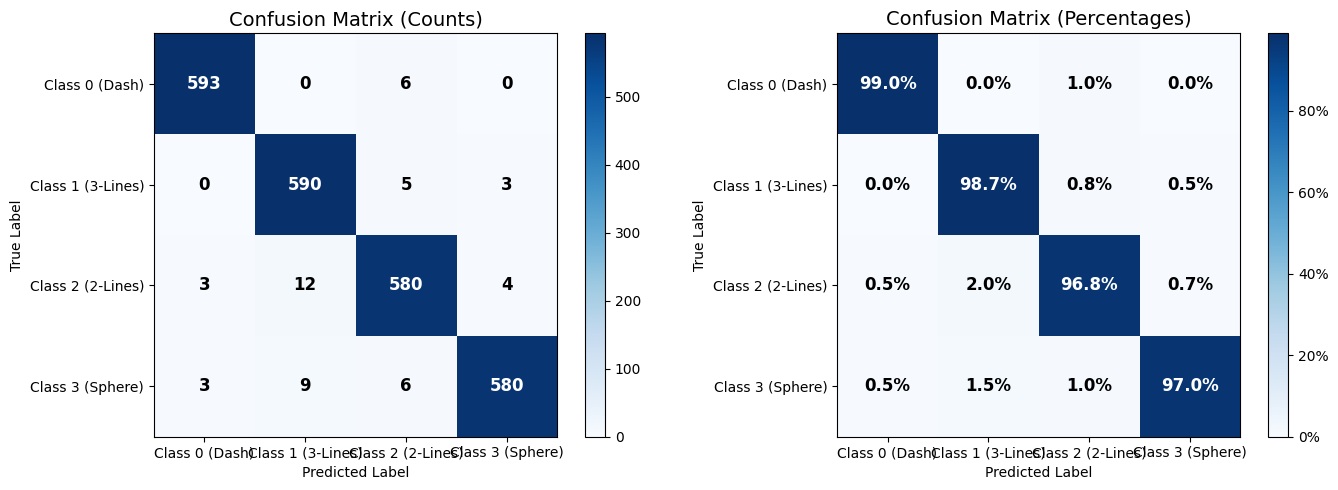


Per-Class Accuracy:
----------------------------------------
Class 0 (Dash): 99.00%
Class 1 (3-Lines): 98.66%
Class 2 (2-Lines): 96.83%
Class 3 (Sphere): 96.99%


In [16]:
# Confusion matrices for baseline
print("BASELINE MODEL - Confusion Matrix:")
plot_confusion_matrices(y_val, y_val_pred_baseline, CLASS_NAMES)


LABEL SMOOTHING MODEL - Confusion Matrix:


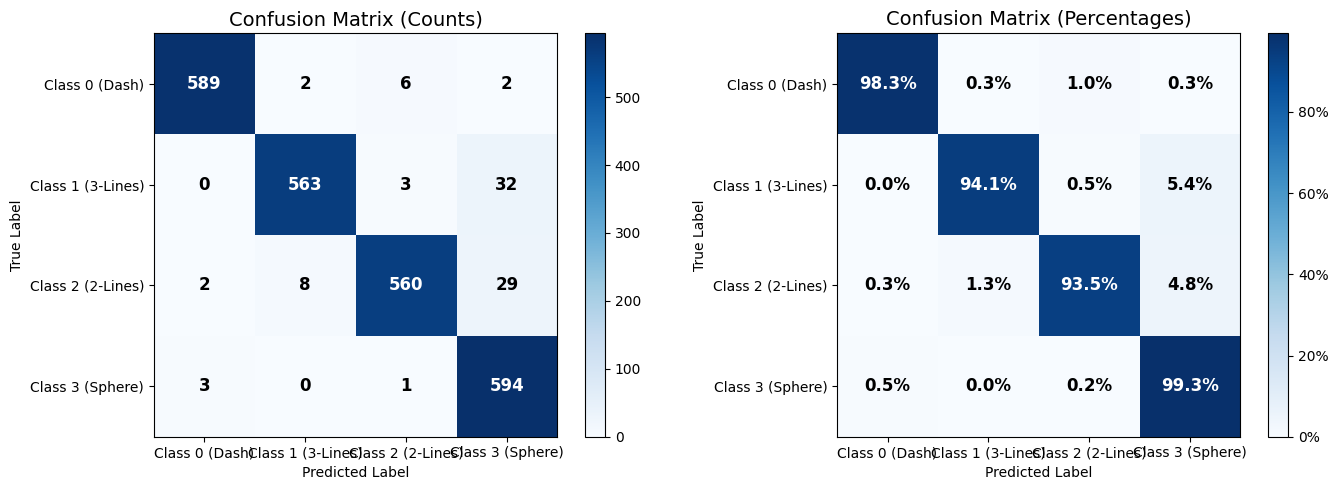


Per-Class Accuracy:
----------------------------------------
Class 0 (Dash): 98.33%
Class 1 (3-Lines): 94.15%
Class 2 (2-Lines): 93.49%
Class 3 (Sphere): 99.33%


In [17]:
# Confusion matrices for label smoothing
print("LABEL SMOOTHING MODEL - Confusion Matrix:")
plot_confusion_matrices(y_val, y_val_pred_smoothing, CLASS_NAMES)


---

## Test Set Evaluation (Final Unbiased Results)


In [18]:
print("TEST SET EVALUATION (Untouched Data)")
print("=" * 70)
print("Note: Test set was split BEFORE preprocessing to avoid data leakage")
print("=" * 70)

# Baseline model on test set (use one-hot labels for evaluation)
baseline_test_loss, baseline_test_accuracy = model_baseline.evaluate(X_test, y_test_onehot, verbose=0)
y_test_pred_baseline = np.argmax(model_baseline.predict(X_test, verbose=0), axis=1)

# Label smoothing model on test set (use one-hot labels for evaluation)
smoothing_test_loss, smoothing_test_accuracy = model_smoothing.evaluate(X_test, y_test_onehot, verbose=0)
y_test_pred_smoothing = np.argmax(model_smoothing.predict(X_test, verbose=0), axis=1)

# Print comparison
print(f"\n{'Metric':<30} {'Baseline':<20} {'Label Smoothing':<20}")
print("-" * 70)
print(f"{'Test Loss':<30} {baseline_test_loss:<20.4f} {smoothing_test_loss:<20.4f}")
print(f"{'Test Accuracy':<30} {baseline_test_accuracy:<20.4f} {smoothing_test_accuracy:<20.4f}")

# Calculate improvement
test_acc_diff = smoothing_test_accuracy - baseline_test_accuracy
print(f"\nTest Accuracy Difference: {test_acc_diff:+.4f} ({'improved' if test_acc_diff > 0 else 'decreased' if test_acc_diff < 0 else 'same'})")


TEST SET EVALUATION (Untouched Data)
Note: Test set was split BEFORE preprocessing to avoid data leakage

Metric                         Baseline             Label Smoothing     
----------------------------------------------------------------------
Test Loss                      0.1268               0.4565              
Test Accuracy                  0.9721               0.9533              

Test Accuracy Difference: -0.0188 (decreased)


In [19]:
# Test set classification reports
print("BASELINE MODEL - Test Set Classification Report:")
print("=" * 70)
print(classification_report(y_test, y_test_pred_baseline, target_names=CLASS_NAMES))

print(f"\nLABEL SMOOTHING MODEL - Test Set Classification Report:")
print("=" * 70)
print(classification_report(y_test, y_test_pred_smoothing, target_names=CLASS_NAMES))


BASELINE MODEL - Test Set Classification Report:
                   precision    recall  f1-score   support

   Class 0 (Dash)       0.99      0.98      0.98       600
Class 1 (3-Lines)       0.96      0.97      0.97       600
Class 2 (2-Lines)       0.96      0.96      0.96       600
 Class 3 (Sphere)       0.98      0.97      0.97       600

         accuracy                           0.97      2400
        macro avg       0.97      0.97      0.97      2400
     weighted avg       0.97      0.97      0.97      2400


LABEL SMOOTHING MODEL - Test Set Classification Report:
                   precision    recall  f1-score   support

   Class 0 (Dash)       0.98      0.98      0.98       600
Class 1 (3-Lines)       0.98      0.92      0.95       600
Class 2 (2-Lines)       0.97      0.94      0.95       600
 Class 3 (Sphere)       0.89      0.98      0.94       600

         accuracy                           0.95      2400
        macro avg       0.96      0.95      0.95      2400
    

BASELINE MODEL - Test Set Confusion Matrix:


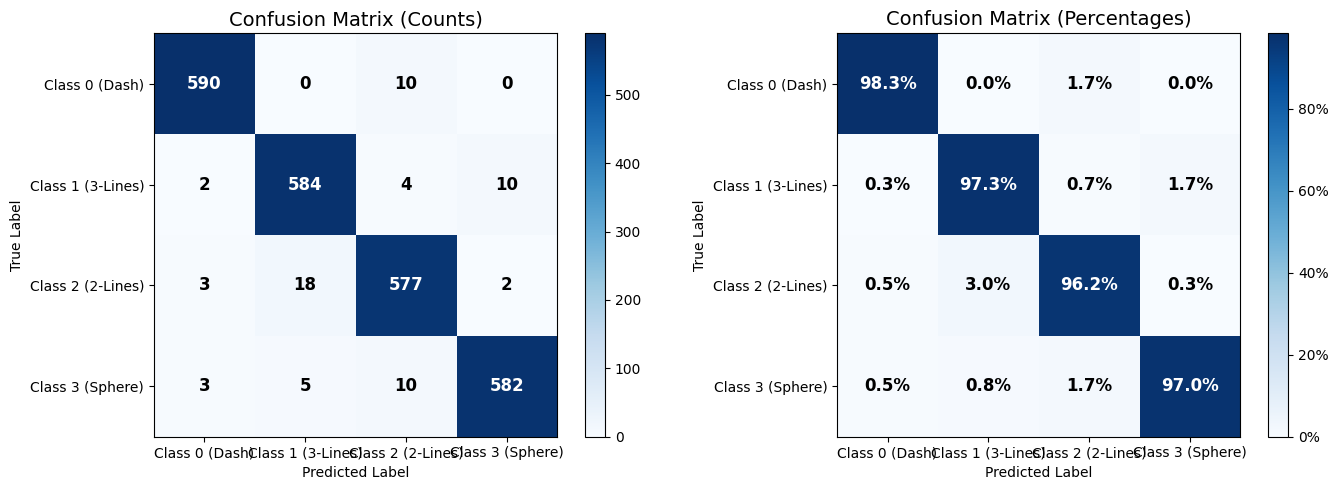


Per-Class Accuracy:
----------------------------------------
Class 0 (Dash): 98.33%
Class 1 (3-Lines): 97.33%
Class 2 (2-Lines): 96.17%
Class 3 (Sphere): 97.00%


In [20]:
# Test set confusion matrices
print("BASELINE MODEL - Test Set Confusion Matrix:")
plot_confusion_matrices(y_test, y_test_pred_baseline, CLASS_NAMES)


LABEL SMOOTHING MODEL - Test Set Confusion Matrix:


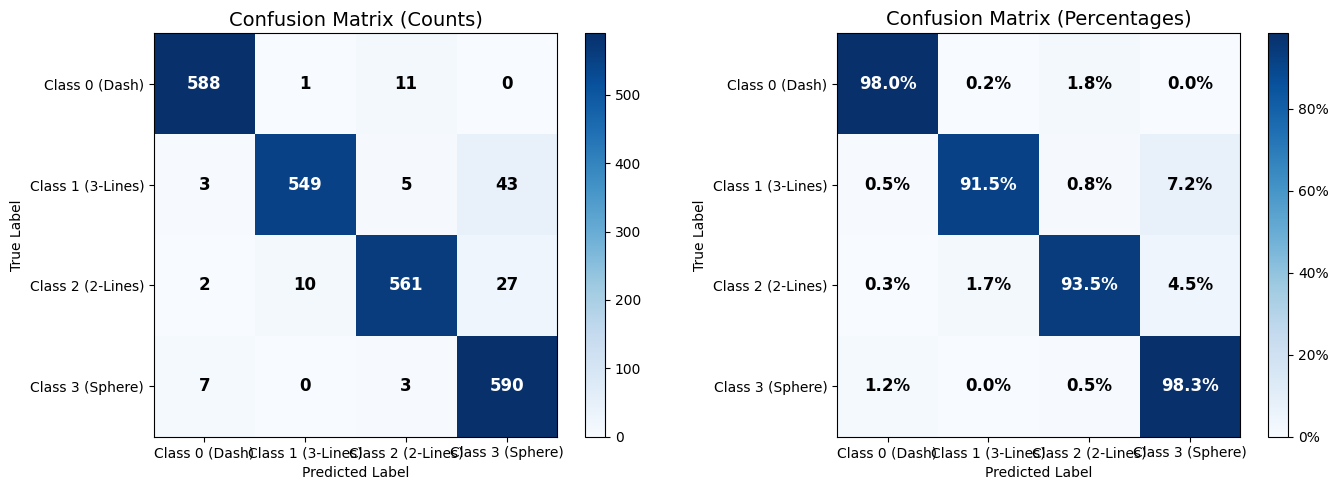


Per-Class Accuracy:
----------------------------------------
Class 0 (Dash): 98.00%
Class 1 (3-Lines): 91.50%
Class 2 (2-Lines): 93.50%
Class 3 (Sphere): 98.33%


In [21]:
print("LABEL SMOOTHING MODEL - Test Set Confusion Matrix:")
plot_confusion_matrices(y_test, y_test_pred_smoothing, CLASS_NAMES)


---

## Prediction Confidence Analysis

One key benefit of label smoothing is better **calibrated** predictions.


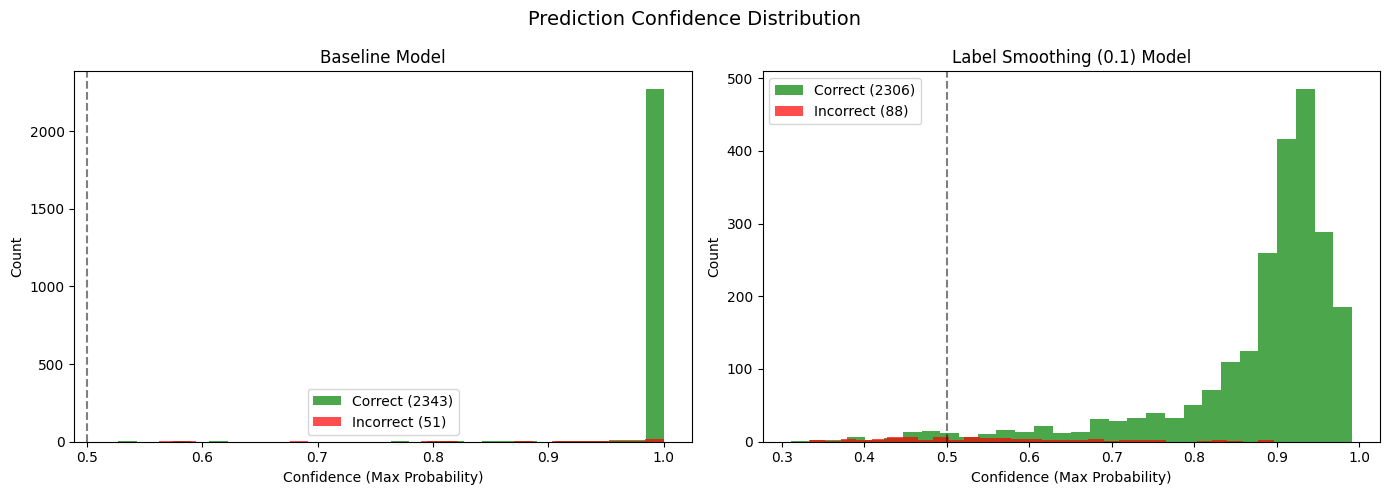


Confidence Statistics:
Metric                                   Baseline        Label Smoothing
----------------------------------------------------------------------
Mean confidence (all)                    0.9927          0.8650         
Mean confidence (correct)                0.9953          0.8766         
Mean confidence (incorrect)              0.8738          0.5614         
Std confidence (all)                     0.0447          0.1264         


In [22]:
# Get prediction probabilities
baseline_probs = model_baseline.predict(X_val, verbose=0)
smoothing_probs = model_smoothing.predict(X_val, verbose=0)

# Get max probability (confidence) for each prediction
baseline_confidence = np.max(baseline_probs, axis=1)
smoothing_confidence = np.max(smoothing_probs, axis=1)

# Separate correct and incorrect predictions
baseline_correct_mask = y_val_pred_baseline == y_val
smoothing_correct_mask = y_val_pred_smoothing == y_val

# Plot confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Confidence Distribution", fontsize=14)

# Baseline
axes[0].hist(baseline_confidence[baseline_correct_mask], bins=30, alpha=0.7, 
             label=f'Correct ({np.sum(baseline_correct_mask)})', color='green')
axes[0].hist(baseline_confidence[~baseline_correct_mask], bins=30, alpha=0.7, 
             label=f'Incorrect ({np.sum(~baseline_correct_mask)})', color='red')
axes[0].set_xlabel('Confidence (Max Probability)')
axes[0].set_ylabel('Count')
axes[0].set_title('Baseline Model')
axes[0].legend()
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

# Label Smoothing
axes[1].hist(smoothing_confidence[smoothing_correct_mask], bins=30, alpha=0.7, 
             label=f'Correct ({np.sum(smoothing_correct_mask)})', color='green')
axes[1].hist(smoothing_confidence[~smoothing_correct_mask], bins=30, alpha=0.7, 
             label=f'Incorrect ({np.sum(~smoothing_correct_mask)})', color='red')
axes[1].set_xlabel('Confidence (Max Probability)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Label Smoothing ({LABEL_SMOOTHING}) Model')
axes[1].legend()
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print statistics
print("\nConfidence Statistics:")
print("=" * 70)
print(f"{'Metric':<40} {'Baseline':<15} {'Label Smoothing':<15}")
print("-" * 70)
print(f"{'Mean confidence (all)':<40} {np.mean(baseline_confidence):<15.4f} {np.mean(smoothing_confidence):<15.4f}")
print(f"{'Mean confidence (correct)':<40} {np.mean(baseline_confidence[baseline_correct_mask]):<15.4f} {np.mean(smoothing_confidence[smoothing_correct_mask]):<15.4f}")
if np.sum(~baseline_correct_mask) > 0 and np.sum(~smoothing_correct_mask) > 0:
    print(f"{'Mean confidence (incorrect)':<40} {np.mean(baseline_confidence[~baseline_correct_mask]):<15.4f} {np.mean(smoothing_confidence[~smoothing_correct_mask]):<15.4f}")
print(f"{'Std confidence (all)':<40} {np.std(baseline_confidence):<15.4f} {np.std(smoothing_confidence):<15.4f}")


---

## Final Summary and Comparison


In [23]:
print("=" * 80)
print("FINAL SUMMARY: BASELINE vs LABEL SMOOTHING")
print("=" * 80)

# Print as table
print(f"\n{'Metric':<35} {'Baseline':<25} {'Label Smoothing':<25}")
print("-" * 85)
print(f"{'Validation Accuracy':<35} {baseline_val_accuracy:.4f} ({baseline_val_accuracy*100:.2f}%){'':<10} {smoothing_val_accuracy:.4f} ({smoothing_val_accuracy*100:.2f}%)")
print(f"{'Validation Loss':<35} {baseline_val_loss:<25.4f} {smoothing_val_loss:<25.4f}")
print(f"{'Test Accuracy':<35} {baseline_test_accuracy:.4f} ({baseline_test_accuracy*100:.2f}%){'':<10} {smoothing_test_accuracy:.4f} ({smoothing_test_accuracy*100:.2f}%)")
print(f"{'Test Loss':<35} {baseline_test_loss:<25.4f} {smoothing_test_loss:<25.4f}")
print(f"{'Epochs Trained':<35} {len(history_baseline.history['loss']):<25} {len(history_smoothing.history['loss']):<25}")
print(f"{'Mean Confidence':<35} {np.mean(baseline_confidence):<25.4f} {np.mean(smoothing_confidence):<25.4f}")

# Final verdict
print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

if smoothing_test_accuracy > baseline_test_accuracy:
    improvement = (smoothing_test_accuracy - baseline_test_accuracy) * 100
    print(f"Label Smoothing IMPROVED test accuracy by {improvement:.2f}%")
elif smoothing_test_accuracy < baseline_test_accuracy:
    decrease = (baseline_test_accuracy - smoothing_test_accuracy) * 100
    print(f"Label Smoothing DECREASED test accuracy by {decrease:.2f}%")
else:
    print(f"Label Smoothing had NO EFFECT on test accuracy")

print(f"\nLabel Smoothing Factor Used: {LABEL_SMOOTHING}")
print(f"\nKey Observations:")
print(f"  - Baseline model mean confidence: {np.mean(baseline_confidence):.4f}")
print(f"  - Label Smoothing model mean confidence: {np.mean(smoothing_confidence):.4f}")
if np.mean(smoothing_confidence) < np.mean(baseline_confidence):
    print(f"  - Label Smoothing produces less overconfident predictions (better calibration)")


FINAL SUMMARY: BASELINE vs LABEL SMOOTHING

Metric                              Baseline                  Label Smoothing          
-------------------------------------------------------------------------------------
Validation Accuracy                 0.9787 (97.87%)           0.9632 (96.32%)
Validation Loss                     0.0894                    0.4420                   
Test Accuracy                       0.9721 (97.21%)           0.9533 (95.33%)
Test Loss                           0.1268                    0.4565                   
Epochs Trained                      34                        14                       
Mean Confidence                     0.9927                    0.8650                   

CONCLUSION
Label Smoothing DECREASED test accuracy by 1.88%

Label Smoothing Factor Used: 0.1

Key Observations:
  - Baseline model mean confidence: 0.9927
  - Label Smoothing model mean confidence: 0.8650
  - Label Smoothing produces less overconfident predictions (better

---

## Save Best Model


In [24]:
# Determine and save the best model
if smoothing_test_accuracy >= baseline_test_accuracy:
    best_model = model_smoothing
    best_model_name = "label_smoothing"
    best_accuracy = smoothing_test_accuracy
else:
    best_model = model_baseline
    best_model_name = "baseline"
    best_accuracy = baseline_test_accuracy

# Save the best model
MODEL_PATH = "model_s3343711_label_smoothing.h5"
best_model.save(MODEL_PATH)

print(f"Best model ({best_model_name}) saved to: {MODEL_PATH}")
print(f"Test accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Model file size: {os.path.getsize(MODEL_PATH) / (1024 * 1024):.2f} MB")


Best model (baseline) saved to: model_s3343711_label_smoothing.h5
Test accuracy: 0.9721 (97.21%)
Model file size: 1.24 MB


---

## Prediction Function


In [25]:
def predict_fn(X32x32: np.ndarray) -> np.ndarray:
    """
    Prediction function using the trained model.
    
    Parameters:
        X32x32: Input images of shape (N, 32, 32) or (32, 32)
    
    Returns:
        Predicted class labels as np.int64 array
    """
    if X32x32.ndim == 2:
        X32x32 = X32x32[np.newaxis, ...]
    
    # Preprocess using TRAINING data statistics
    X_normalized = (X32x32 - PIXEL_MIN) / (PIXEL_MAX - PIXEL_MIN)
    X_normalized = np.clip(X_normalized, 0, 1)
    X_preprocessed = X_normalized[..., np.newaxis].astype(np.float32)
    
    # Get predictions
    predictions_proba = best_model.predict(X_preprocessed, verbose=0)
    predictions = np.argmax(predictions_proba, axis=1).astype(np.int64)
    
    return predictions


# Test the predict_fn
print("Testing predict_fn with test samples...")
test_samples = X_test_raw[:5]
test_predictions = predict_fn(test_samples)
print(f"Input shape: {test_samples.shape}")
print(f"Output shape: {test_predictions.shape}")
print(f"Predicted labels: {test_predictions}")
print(f"True labels: {y_test[:5]}")
print(f"Correct: {np.sum(test_predictions == y_test[:5])}/5")


Testing predict_fn with test samples...
Input shape: (5, 32, 32)
Output shape: (5,)
Predicted labels: [2 1 2 3 0]
True labels: [2 1 2 3 0]
Correct: 5/5


---

## Experiment Conclusion

### What is Label Smoothing?
Label smoothing is a regularization technique that replaces hard one-hot encoded labels with soft labels. Instead of training the model to be 100% confident in its predictions, we train it to be slightly less certain.

### Why Label Smoothing Might Help
1. **Prevents overconfidence**: The model doesn't learn to output extreme probabilities
2. **Better calibration**: Predicted probabilities better reflect actual likelihoods
3. **Implicit regularization**: Acts as a form of regularization that can improve generalization

### Dataset Characteristics
The dataset has 4 classes with distinct visual patterns:
- **Class 0**: Dash-like shape
- **Class 1**: Three parallel lines
- **Class 2**: Two parallel lines
- **Class 3**: Sphere/circular shape

### Results Summary
This experiment compared:
- **Baseline**: Standard cross-entropy loss with hard labels
- **Label Smoothing**: Cross-entropy loss with soft labels (smoothing factor = 0.1)

The results demonstrate whether label smoothing improves or hurts performance on this specific dataset with its distinct visual patterns.

**Student ID:** s3343711
